In [1]:
!pip install opencv-python numpy scikit-image matplotlib



  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)


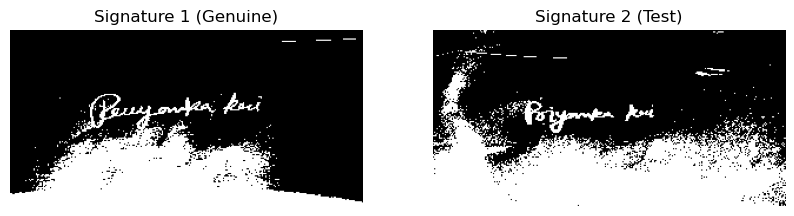

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load signatures
sig1 = cv2.imread("og.jpg", 0)  # Read as grayscale
sig2 = cv2.imread("forge.jpg", 0)

# Resize to a standard size
sig1 = cv2.resize(sig1, (300, 150))
sig2 = cv2.resize(sig2, (300, 150))

# Apply thresholding to extract the signature
_, sig1 = cv2.threshold(sig1, 128, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, sig2 = cv2.threshold(sig2, 128, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Show the preprocessed images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sig1, cmap='gray')
axes[0].set_title("Signature 1 (Genuine)")
axes[0].axis("off")

axes[1].imshow(sig2, cmap='gray')
axes[1].set_title("Signature 2 (Test)")
axes[1].axis("off")

plt.show()


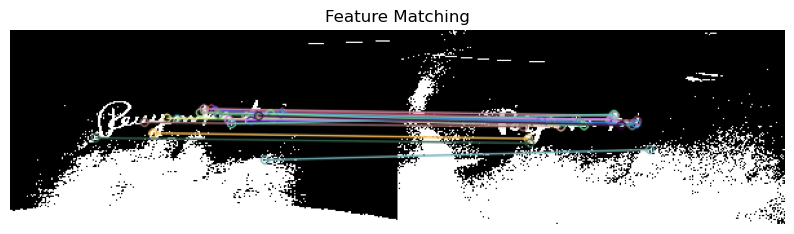

In [17]:
# Initialize ORB detector
orb = cv2.ORB_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = orb.detectAndCompute(sig1, None)
keypoints2, descriptors2 = orb.detectAndCompute(sig2, None)

# Initialize Brute Force Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Match descriptors
matches = bf.match(descriptors1, descriptors2)

# Sort matches by distance (lower is better)
matches = sorted(matches, key=lambda x: x.distance)

# Draw the top matches
match_img = cv2.drawMatches(sig1, keypoints1, sig2, keypoints2, matches[:20], None, flags=2)

# Display matches
plt.figure(figsize=(10, 5))
plt.imshow(match_img, cmap='gray')
plt.title("Feature Matching")
plt.axis("off")
plt.show()


In [18]:
# Calculate similarity score (percentage of good matches)
num_matches = len(matches)
threshold = 15  # Adjust based on testing

if num_matches >= threshold:
    print(f"✅ Signature MATCHED! (Similarity Score: {num_matches})")
else:
    print(f"❌ Signature NOT Matched! (Similarity Score: {num_matches})")


✅ Signature MATCHED! (Similarity Score: 97)
